LIBRARIES

In [29]:
import numpy as np
from numpy.fft import fft, fftfreq, fftshift, rfft, rfftfreq
import matplotlib.pyplot as plt
import pandas as pd
import scipy.signal as sig
from scipy.signal import butter, filtfilt, iirnotch, find_peaks, welch
from scipy.integrate import cumulative_trapezoid 

DATA LOADING

In [30]:
from pathlib import Path

#load delsys recording in a csv/xlmx format and extract sEMG abd gyroscope signals
#returns a sEMG signals data frame in mV and a gyroscope signal dataframe, each one with its corresponding time vectors
def load_delsys_data(file_path, fs):
    if file_path.endswith('csv'):
        df = pd.read_csv(file_path, sep=';', decimal=',') #if it is in a csv format
    else:
        df = pd.read_excel(file_path) #if it is in a xlmx format

    #extract sEMG data and sEMG time
    emg_df = df.iloc[:, [0, 1, 3]].copy()
    emg_df.columns = ["time_emg", "biceps", "triceps"]
    #converts all values to numeric, replacing invalid values with NaN, then removes rows containing missing values
    emg_df = emg_df.apply(pd.to_numeric, errors = 'coerce').dropna() #dropna eliminates lines with NaN values

    #transform from V to mV
    emg_df["biceps"] = emg_df["biceps"] * 1000
    emg_df["triceps"] = emg_df["triceps"] * 1000

    #extract ROM data and time
    gyro_df = df.iloc[:, [16, 17]].copy()
    gyro_df.columns = ["time_gyro", "gyro_z"]
    gyro_df = gyro_df.apply(pd.to_numeric, errors = 'coerce').dropna()

    return emg_df, gyro_df

#load all delsys recordings organized by participants and experimental sessions
#returns a dataset containing filename, sEMG and gyroscope data for each trial 
def load_dataset(base_folder, fs):
    dataset = {}
    base_dir = Path(base_folder)
    
    for patient_folder in base_dir.iterdir():
        if patient_folder.is_dir():
            patient_name = patient_folder.name
            dataset[patient_name] = {"control": [], "fmv": []}
            
            #load recordings from control session
            control_csv = sorted((patient_folder / "control").glob("*.csv"))
            
            for file in control_csv:
                emg_df, gyro_df = load_delsys_data(str(file), fs)
                dataset[patient_name]["control"].append({
                    "file": file.name, "emg": emg_df, "gyro": gyro_df}) #store the extracted signals
                
            #load recordings from fmv session
            fmv_csv = sorted((patient_folder / "fmv").glob("*.csv"))
            
            for file in fmv_csv:
                emg_df, gyro_df = load_delsys_data(str(file), fs)
                dataset[patient_name]["fmv"].append({
                    "file": file.name, "emg": emg_df, "gyro": gyro_df})
    return dataset

SIGNAL SYNCHRONIZATION

In [31]:
#calculates an amplitude threshold based on the mean and standard deviation of the signal
#returns the threshold value
def calculate_threshold(signal):
    average = np.mean(signal) #mean
    var = np.std(signal) #standard deviation
    
    threshold = average + (2 * var)
    
    return threshold

#detects activation peaks in the signal using an adaptative amplitude threshold
#returns the number of peaks, their respective indexes, values and threshold 
def detect_activation_peaks(signal):
    fs = 2148
    threshold = calculate_threshold(signal)
    
    min_distance = int(0.5 * fs) #minimum distance between peaks, set at 0.5 seconds

    #detect peaks higher than the threshold and separated by the minimum distance
    peaks, properties = find_peaks(signal, height = threshold, distance = min_distance)
    
    return{
        "number_peaks": len(peaks), "peaks": peaks, "peak_values": signal[peaks], "threshold": threshold
    }

#synchronize sEMG and ROM signals by detecting the beginning of movement
#returns the trials cut from the movement onset and the signals on the same length
def synchronize_signals(trials):
    fs_gyro = 1074
    baseline_sec = 5
    
    synchronized_trials = []
    
    for trial in trials:
        emg_data = trial["emg"]
        gyro_data = trial["gyro"]

        #remove all the remaining recording once the movement has stopped
        last_gyro_index = gyro_data["time_gyro"].idxmax()
        gyro_data = gyro_data.loc[:last_gyro_index].copy()
        
        gyro_signal = gyro_data["gyro_z"].values
        gyro_time = gyro_data["time_gyro"].values
        emg_time = emg_data["time_emg"].values
        
        gyro_abs = np.abs(gyro_signal) #absolute signal to detect movement independently of the direction

        #define the resting baseline using the first 5 seconds of the recording
        baseline_end = np.searchsorted(gyro_time, baseline_sec)
        baseline = gyro_abs[:baseline_end]

        #adaptative threshold to detect movement
        movement_threshold = np.mean(baseline) + 3 * np.std(baseline)
        
        #search for movement after 5 seconds of rest
        movement_part = gyro_abs[baseline_end:]
        movement_points = np.where(movement_part > movement_threshold)[0]

        #if no movement is detected, skip that trial
        if len(movement_points) == 0:
            print(f"No movement found in {trial["file"]}")
            continue

        #obtain the first movement and its corresponding time
        first_movement = movement_points[0] + baseline_end
        start_time = gyro_time[first_movement]

        #find the equivalent starting indexes in the sEMG and gyroscope time vectors
        emg_start_index = np.searchsorted(emg_time, start_time)
        gyro_start_index = np.searchsorted(gyro_time, start_time)

        #cut both signals
        emg_cut = emg_data.iloc[emg_start_index:].copy()
        gyro_cut = gyro_data.iloc[gyro_start_index:].copy()
        
        if len(emg_cut) == 0 or len(gyro_cut) == 0:
            print(f"Empty cut in {trial["file"]}")
            continue
            
        emg_cut["time_emg"] = emg_cut["time_emg"] - start_time
        gyro_cut["time_gyro"] = gyro_cut["time_gyro"] - start_time

        #calculate ROM
        rom_cut = calculate_rom(gyro_cut)
        
        processed_cut = {
            "biceps": {}, "triceps": {}, "rom": rom_cut
        }
        #cut all sEMG signals using the same sEMG starting index
        for muscle in ["biceps", "triceps"]:
            for i, values in trial["processed"][muscle].items():
                if np.isscalar(values):
                    processed_cut[muscle][i] = values
                else:
                    processed_cut[muscle][i] = np.asarray(values)[emg_start_index:]
                    
        synchronized_trials.append({
            "file": trial["file"],
            "emg": emg_cut.reset_index(drop = True),
            "gyro": gyro_cut.reset_index(drop = True),
            "processed": processed_cut,
            "start_time": start_time
        })
        
    if len(synchronized_trials) == 0:
        return []

    #find shortest sEMG and gyroscope lengths across all trials
    min_len_emg = min(len(trial["emg"]) for trial in synchronized_trials)
    min_len_gyro = min(len(trial["gyro"]) for trial in synchronized_trials)

    #cut all trials to the same length
    for trial in synchronized_trials:
        trial["emg"] = trial["emg"].iloc[:min_len_emg].reset_index(drop = True)
        trial["gyro"] = trial["gyro"].iloc[:min_len_gyro].reset_index(drop = True)
        trial["processed"]["rom"] = trial["processed"]["rom"][:min_len_gyro] 
        
        for muscle in ["biceps", "triceps"]:
            for i, values in trial["processed"][muscle].items():
                if not np.isscalar(values):
                    trial["processed"][muscle][i] = np.asarray(values)[:min_len_emg]
                    
    return synchronized_trials

#apply signal synchronization to every patient and experimental session in the global dataset
#returns the dataset with the synchronized trials
def synchronize_dataset(dataset):
    for patient in dataset:
        for session in ["control", "fmv"]:
            if len(dataset[patient][session]) > 0:
                dataset[patient][session] = synchronize_signals(dataset[patient][session])
            else:
                print(f"{patient} has no {session} trials")
        
    return dataset

FILTERING FUNCTIONS

In [32]:
#apply a Butterworth band-pass filter 
#returns the filtered signal after removing the low and high frequency noise
def bandpass_filt(signal, fs, lowcut, highcut, order):
    freq = fs/2 #nyq
    
    #normalize with respect to the Nyq freq
    low = lowcut / freq
    high = highcut / freq
    
    b, a = butter(order, [low, high], btype = "bandpass")
    filtered_signal = filtfilt(b, a, signal)
    
    return filtered_signal

#apply notch filter to remove power line interference from the signal
#returns the filtered signal with the 50 Hz noise attenuated
def notch_filter(signal, fs):
    notch_freq = 50
    Q = 30
    freq = fs / 2 #nyquist frequency
    wo = notch_freq / freq #normalize with respect to the Nyq freq
    
    b, a = iirnotch(wo, Q)
    filtered_signal = filtfilt(b, a, signal)
    
    return filtered_signal

#rectify the sEMG signal by converting everything to positive values
def rectify_emg(signal):
    rectified_signal = np.abs(signal)
    return rectified_signal

#calculates the linear envelope of the rectified sEMG signal using a low-pass filters
#returns a smoothed signal which represents the muscle activation
def linear_envelope(signal, fs, cutoff, order):
    freq = fs / 2 #nyquist frequency
    cutoff_freq = cutoff / freq
    
    b, a = butter(order, cutoff_freq, btype = "low")
    envelope = filtfilt(b, a, signal)
    
    return envelope

#remove extreme amplitude spikes
#returns a cleaned signal where outlier values are limited to the percentile range
def remove_spikes(signal):
    lower_percentile = 0.5
    upper_percentile = 99.5
    
    signal = np.asarray(signal).copy()
    
    lower_limit = np.percentile(signal, lower_percentile)
    upper_limit = np.percentile(signal, upper_percentile)

    #clip extreme values outside the percentile range
    clean_signal = np.clip(signal, lower_limit, upper_limit)
    return clean_signal

ROM PROCESSING

In [33]:
#calculates ROM by integrating the angular velocity signal over time
def calculate_rom(gyro_data):
    rom_degrees = cumulative_trapezoid(gyro_data["gyro_z"], gyro_data["time_gyro"], initial = 0)
    return rom_degrees

#bormalize a signal between 0 and 1 using max-min normalization
def normalize_signal(signal):
    min = np.min(signal)
    max = np.max(signal)
    
    if (max - min) == 0:
        return signal
        
    normalized_signal = ((signal - min) / (max - min))
    
    return normalized_signal

EXECUTABLE SIGNAL PROCESSING FUNCTIONS

In [34]:
#applies all the filtering and preprocessing steps
def apply_filtering(signal, plot = False):
    fs = 2148

    #Bandpass data
    bp_low = 20
    bp_high = 450
    bp_order = 4
    
    #Envelope data
    lp_cutoff = 5
    lp_order = 4

    #First --> remove spikes (noise)
    signal = remove_spikes(signal)
    
    #1. Bandpass filtering
    bandpass_signal = bandpass_filt(signal, fs, bp_low, bp_high, bp_order)
    
    #2. Notch filering
    notch_signal = notch_filter(bandpass_signal, fs)
    
    #3. Rectification
    rectified_signal = rectify_emg(notch_signal)
    
    #4. Linear envelope
    envelope_signal = linear_envelope(rectified_signal, fs, lp_cutoff, lp_order)
    
    return {"raw": signal, "bandpass": bandpass_signal, "notch": notch_signal, "rectified": rectified_signal, "envelope": envelope_signal}

#process all sEMG and gyroscope recordings in the dataset
#returns the dataset with the processed biceps brachii, triceps brachii and ROM
def process_dataset(dataset):
    for patient in dataset:
        for session in ["control", "fmv"]:
            for trial in dataset[patient][session]:
                
                #apply sEMG filtering to biceps and triceps signals
                bic_processed = apply_filtering(trial["emg"]["biceps"])
                tric_processed = apply_filtering(trial["emg"]["triceps"])
                
                #baseline correction over the linear envelope
                bic_processed["envelope_corrected"], bic_processed["envelope_threshold"] = baseline_correction(bic_processed["envelope"])
                tric_processed["envelope_corrected"], tric_processed["envelope_threshold"] = baseline_correction(tric_processed["envelope"])
                
                rom = calculate_rom(trial["gyro"])
                trial["processed"] = {"biceps": bic_processed, "triceps": tric_processed, "rom": rom}

    return dataset  

FEATURE EXTRACTION

In [35]:
#calculate RMS using a sliding window
def rms_sliding_window(signal, fs = 2148, window_sec = 0.25):
    wind_size = int(window_sec * fs) #calculates the window size in samples
    squared_signal = signal ** 2

    #compite RMS using a moving average of the squared signal
    rms = np.sqrt(np.convolve(squared_signal, np.ones(wind_size)/wind_size, mode = "valid"))
    return rms

#applies baseline correction to the sEMG envelope using the initial resting period
#returns the baseline corrected signal and the threshold used for correction
def baseline_correction(signal, fs = 2148, sec = 5):
    signal = np.asarray(signal).copy()

    #define the baseline window using the first seconds of the recording
    baseline_points = int(sec * fs)
    baseline_window = signal[:baseline_points]

    threshold = np.mean(baseline_window) + 2 * np.std(baseline_window)
    corrected = signal - threshold #substract the baseline threshold from the signal
    
    corrected[corrected < 0] = 0 #set negative values resulting from the substraction to 0
    
    return corrected, threshold

#calculate the mean RMS value from the envelope
#returns a single RMS value representing the average signal amplitude
def calculate_rms(envelope, fs = 2148, window_sec = 0.25):
    rms_signal = rms_sliding_window(envelope, fs = fs, window_sec = window_sec)
    rms_value = np.mean(rms_signal)
    return rms_value

#calculate the ratio between a value and its corresponding baseline value
#returns the normalized ratio or NaN if the baseline is 0
def calculate_ratio(value, baseline_value):
    if baseline_value == 0:
        return np.nan
        
    return (value / baseline_value)

#calculate the CI between biceps and triceps
def calculate_coactivation_index(biceps, triceps):
    biceps = np.asarray(biceps)
    triceps = np.asarray(triceps)
    
    common_area = np.minimum(biceps, triceps) #common area of activation between both muscles

    #integrate activation areas
    area_both = np.trapz(common_area)
    area_biceps = np.trapz(biceps)
    area_triceps = np.trapz(triceps)
    
    denominator = area_biceps + area_triceps
    
    if denominator == 0:
        return np.nan
        
    ci = 2 * (area_both / denominator) * 100
    
    return ci

#calculate MNF of an sEMG signal using PSD
def calculate_mnf(signal, fs):
    #estimate the PSD using Welch's method
    freq, psd = welch(signal, fs = fs, nperseg = 512)
    
    mnf = ((np.sum(freq * psd)) / (np.sum(psd)))
    return mnf

EXECUTABLE FEATURE EXTRACTION

In [36]:
#extract main sEMG features from each trial 
#returns a dataframe with all the metrics: RMS, CI and MNF
def feature_extraction(dataset, fs = 2148):
    results = []
    
    for patient in dataset:
        for session in ["control", "fmv"]:
            trials = dataset[patient][session]
            
            if len(trials) == 0:
                continue
                
            baseline = trials[0] #first recording of each session
            
            baseline_bic = baseline["processed"]["biceps"]
            baseline_tric = baseline["processed"]["triceps"]
            baseline_rom = baseline["processed"]["rom"]
            
            
            #baseline rms
            baseline_bic_rms = calculate_rms(baseline_bic["envelope_corrected"], fs = fs)
            baseline_tric_rms = calculate_rms(baseline_tric["envelope_corrected"], fs = fs)
            
            #baseline ci
            baseline_ci = calculate_coactivation_index(baseline_bic["envelope_corrected"], baseline_tric["envelope_corrected"])
            
            #baseline mnf
            baseline_bic_mnf = calculate_mnf(baseline_bic["notch"], fs)
            baseline_tric_mnf = calculate_mnf(baseline_tric["notch"], fs)

            #extract features from each trial in the session
            for i, trial in enumerate(trials, start = 1):
                bic = trial["processed"]["biceps"]
                tric = trial["processed"]["triceps"]
                rom = trial["processed"]["rom"]
                
                #RMS
                bic_rms = calculate_rms(bic["envelope_corrected"], fs = fs)
                tric_rms = calculate_rms(tric["envelope_corrected"], fs = fs)
                
                bic_rms_ratio = calculate_ratio(bic_rms, baseline_bic_rms)
                tric_rms_ratio = calculate_ratio(tric_rms, baseline_tric_rms)
                

                #CI
                ci = calculate_coactivation_index(bic["envelope_corrected"], tric["envelope_corrected"])
                ci_ratio = calculate_ratio(ci, baseline_ci)
                

                #MNF
                bic_mnf = calculate_mnf(bic["notch"], fs)
                tric_mnf = calculate_mnf(tric["notch"], fs)
                                
                bic_mnf_ratio = calculate_ratio(bic_mnf, baseline_bic_mnf)
                tric_mnf_ratio = calculate_ratio(tric_mnf, baseline_tric_mnf)

                
                results.append({
                    "patient": patient,
                    "session": session,
                    "trial": i,
                    "file": trial["file"],
                    "biceps_rms": bic_rms,
                    "triceps_rms": tric_rms,
                    "biceps_rms_ratio": bic_rms_ratio,
                    "triceps_rms_ratio": tric_rms_ratio,
                    "coactivation_index": ci,
                    "coactivation_index_ratio": ci_ratio,
                    "biceps_mnf": bic_mnf,
                    "triceps_mnf": tric_mnf,
                    "biceps_mnf_ratio": bic_mnf_ratio,
                    "triceps_mnf_ratio": tric_mnf_ratio
                })
    return pd.DataFrame(results)

SIGNAL PROCESSING AND FILTERING VISUALIZATION FUNCTIONS

In [37]:
#visualize the main sEMG filtering steps for one trial
def visualize_filtering_steps(trial):
    time = trial["emg"]["time_emg"] #time vector
    
    bic_raw = trial["emg"]["biceps"].values
    tric_raw = trial["emg"]["triceps"].values
    
    bic = apply_filtering(bic_raw)
    tric = apply_filtering(tric_raw)

    #baseline correction
    bic_corr, bic_threshold = baseline_correction(bic["envelope"])
    tric_corr, tric_threshold = baseline_correction(tric["envelope"])

    rom = calculate_rom(trial["gyro"])
    
    fig, axs = plt.subplots(3, 1, figsize = (10, 8), constrained_layout = True)
    fig.suptitle(f"Signal processing {trial['file']}", fontsize = 16, fontweight = "bold")
    
    #plot 1 --> raw signal with 5 seconds of rest
    axs[0].plot(time, bic_raw, color = "blue", alpha = 1, label = "Biceps raw")
    axs[0].plot(time, tric_raw, color = "red", alpha = 1, label = "Triceps raw")
    axs[0].axvspan(0, 5, color = "gray", alpha = 0.2, label = "5s baseline")
    
    axs[0].set_title("(a) Raw sEMG signal with 5s baseline", pad = 12, fontsize = 14)
    axs[0].set_ylabel("Voltage (mV)", fontsize = 12)
    axs[0].set_xlabel("Time (s)", fontsize = 12)
    axs[0].legend(loc = "upper left", fontsize = 9)
    
    #plot 2 --> filtered signals
    axs[1].plot(time, bic["notch"], color = "blue", alpha = 0.25, label = "Biceps filtered")
    axs[1].plot(time, tric["notch"], color = "red", alpha = 0.25, label = "Triceps filtered")
    axs[1].plot(time, bic["envelope"], color = "blue", alpha = 1, label = "Biceps envelope")
    axs[1].plot(time, tric["envelope"], color = "red", alpha = 1, label = "Triceps envelope")
    axs[1].axvspan(0, 5, color = "gray", alpha = 0.2, label = "5s baseline")

    axs[1].set_title("(b) Filtered signal and linear envelope", pad = 12, fontsize = 14)
    axs[1].set_ylabel("Voltage (mV)", fontsize = 12)
    axs[1].set_xlabel("Time (s)", fontsize = 12)
    axs[1].legend(loc = "upper left", fontsize = 9)

    
    #plot 3 --> baseline correction
    axs[2].plot(time, bic_corr, color = "blue", linewidth = 1, label = "Biceps corrected envelope")
    axs[2].plot(time, tric_corr, color = "red", linewidth = 1, label = "Triceps corrected envelope")
    axs[2].axvspan(0, 5, color = "gray", alpha = 0.2)
    
    axs[2].set_title("(c) Baseline-corrected envelope", pad = 12, fontsize = 14)
    axs[2].set_ylabel("Voltage (mV)", fontsize = 12)
    axs[2].set_xlabel("Time (s)", fontsize = 12)
    axs[2].legend(loc = "upper left", fontsize = 9)


    plt.show()

#visualize sEMG signals in both time and frequency domains
def visualize_frequency_processing(trial):
    fs = 2148
    
    time = trial["emg"]["time_emg"].values
    bic_raw = trial["emg"]["biceps"].values
    tric_raw = trial["emg"]["triceps"].values

    bic_filt = apply_filtering(bic_raw)["notch"]
    tric_filt = apply_filtering(tric_raw)["notch"]

    freq_bic, psd_bic = welch(bic_filt, fs = fs, nperseg = 512)
    freq_tric, psd_tric = welch(tric_filt, fs = fs, nperseg = 512)

    fig, axs = plt.subplots(2, 1, figsize = (10, 8), constrained_layout = True)
    fig.suptitle(f"Frequency domain processing ({trial["file"]})", fontsize = 14, fontweight = "bold")

    #plot 1 --> filtered signal
    axs[0].plot(time, bic_filt, color = "blue", linewidth = 1, alpha = 1, label = "Biceps")
    axs[0].plot(time, tric_filt, color = "red", linewidth = 1, alpha = 1, label = "Triceps")
    axs[0].set_title("(a) Bandpass and notch filtered sEMG signal", fontsize = 14)
    axs[0].set_xlabel("Time (s)")
    axs[0].set_ylabel("Voltage (mV)")
    axs[0].legend()

    #plot 2 --> frequency domain
    axs[1].plot(freq_bic, psd_bic, color = "blue", linewidth = 1, label = "Biceps")
    axs[1].plot(freq_tric, psd_tric, color = "red", linewidth = 1, label = "Triceps")
    
    axs[1].set_title("(b) Power Spectral Density (PSD)", fontsize = 14)
    axs[1].set_xlabel("Frequency (Hz)", fontsize = 12)
    axs[1].set_ylabel("PSD (mV²/Hz)", fontsize = 12)
    axs[1].set_xlim(0, 500)
    axs[1].set_yscale("log")
    axs[1].legend()
    
    plt.show()

STATISTICAL ANALYSIS

In [38]:
import statsmodels.formula.api as smf

#prepare the features dataframe for LMM analysis
def lmm_data(features_df):
    df = features_df.copy()

    #convert trial number into experimental timepoint labels
    df["timepoint"] = df["trial"].map({
        1: "Pre", 2: "Post", 3: "Post10", 4: "Post20"
    })
    #define session and timepoint as categorical variables
    df["session"] = pd.Categorical(df["session"], categories = ["control", "fmv"])
    df["timepoint"] = pd.Categorical(df["timepoint"], categories = ["Pre", "Post", "Post10", "Post20"], ordered = True)
    df["patient"] = df["patient"].astype("category") #define patient as a categorical variable for random effects
    
    return df

#apply logarithmic transformation to a selected variable
def add_log_variable(df, variable):
    df = df.copy()
    log_variable = f"log_{variable}"
    
    df = df[df[variable] > 0].copy() #keep only positive values (log is not defined for 0 or neg values)
    df[log_variable] = np.log(df[variable])

    return df, log_variable

#1. INTRA-SESSION (Pre vs Post/Post10/Post20 for each session)
#intra-session LMM comparing each timepoint against Pre
def run_lmm_intra(features_df, variable, session):
    df = lmm_data(features_df) #prepare df
    df, log_variable = add_log_variable(df, variable) #apply log transformation

    df = df[df["session"] == session].copy()

    #fit mixed model with timepoint as fixed effect and patient as random effect
    model = smf.mixedlm(f"{log_variable} ~ C(timepoint)", data = df, groups = df["patient"])
    
    result = model.fit(reml = False)
    
    return result

#extract intra-session p-values from the LMM results
def get_intra_pvalues(features_df, variable, session):
    result = run_lmm_intra(features_df, variable, session) 
    p_values = {
        "Pre": np.nan, 
        "Post": result.pvalues.get("C(timepoint)[T.Post]", np.nan),
        "Post10": result.pvalues.get("C(timepoint)[T.Post10]", np.nan),
        "Post20": result.pvalues.get("C(timepoint)[T.Post20]", np.nan)
    }
    return p_values

#2. INTER-SESSION (FMV vs Control)
#inter-session LMM comparing FMV against Control at one timepoints
def run_lmm_inter(features_df, variable, timepoint):
    df = lmm_data(features_df) #prepare df
    df, log_variable = add_log_variable(df, variable) #apply log transformation

    df = df[df["timepoint"] == timepoint].copy()

    #fit a mixed model with session as fixed effect and patient as random effect
    model = smf.mixedlm(f"{log_variable} ~ C(session)", data = df, groups = df["patient"])
    
    result = model.fit(reml = False)
    
    return result

#extract the inter-session p-value from the LMM result
def get_inter_pvalues(features_df, variable, timepoint):
    result = run_lmm_inter(features_df, variable, timepoint)
    
    p_value = result.pvalues.get("C(session)[T.fmv]", np.nan)
    return p_value

#format p-values for summary tables
def pvalue_format(p):
    if pd.isna(p):
        return "NA"
    elif p < 0.001:
        return "p < 0.001"
    else:
        return f"p = {p:.3f}"

#calculate mean and standard deviation for summary tables
def mean_and_sd(features_df, variable, session, trial):
    values = features_df[(features_df["session"] == session) & (features_df["trial"] == trial)][variable]
    return f"{values.mean():.3f} ± {values.std():.3f}"

#generate intra-session summmary table for all the sEMG metrics
def lmm_intra_summary(features_df):
    variables = {
        "biceps_rms_ratio": "Biceps RMS ratio",
        "triceps_rms_ratio": "Triceps RMS ratio",
        "coactivation_index_ratio": "CI ratio",
        "biceps_mnf_ratio": "Biceps MNF ratio",
        "triceps_mnf_ratio": "Triceps MNF ratio"
    }
    
    rows = []

    #calculate intra-session statistics for each variable and session
    for variable, name in variables.items():
        for session in ["control", "fmv"]:
            pvals = get_intra_pvalues(features_df, variable, session)
            rows.append({
                "Variable": name,
                "Session": session,
                "Pre": mean_and_sd(features_df, variable, session, 1),
                "Post": mean_and_sd(features_df, variable, session, 2) + "," + pvalue_format(pvals["Post"]),
                "Post10": mean_and_sd(features_df, variable, session, 3) + "," + pvalue_format(pvals["Post10"]),
                "Post20": mean_and_sd(features_df, variable, session, 4) + "," + pvalue_format(pvals["Post20"]),
            })
            
    return pd.DataFrame(rows)

#generate inter-session summmary table for all the sEMG metrics
def lmm_inter_summary(features_df):
    variables = {
        "biceps_rms_ratio": "Biceps RMS ratio",
        "triceps_rms_ratio": "Triceps RMS ratio",
        "coactivation_index_ratio": "CI ratio",
        "biceps_mnf_ratio": "Biceps MNF ratio",
        "triceps_mnf_ratio": "Triceps MNF ratio"
    }
    
    rows = []
    
    #calculate inter-session statistics for each variable and session
    for variable, name in variables.items():
        for trial, timepoint in zip([2, 3, 4], ["Post", "Post10", "Post20"]):
            p = get_inter_pvalues(features_df, variable, timepoint)
            rows.append({
                "Variable": name,
                "Timepoint": timepoint,
                "Control": mean_and_sd(features_df, variable, "control", trial),
                "FMV": mean_and_sd(features_df, variable, "fmv", trial),
                "FMV vs Control": pvalue_format(p)
            })
    return pd.DataFrame(rows)

RESULT PLOTS

In [39]:
from matplotlib.patches import Patch

#plot RMS ratio boxplots for biceps and triceps across all timepoints
#shows Control and FMV distribution together with mean trends over time
def plot_rms_boxplots(features_df):
    df = features_df.copy()
    
    time_labels = {1: "Pre", 2: "Post", 3: "Post10", 4: "Post20"}
    figs, axs = plt.subplots(2, 1, figsize = (12, 10))

    positions_control = np.array([1, 2, 3, 4]) - 0.125
    positions_fmv = np.array([1, 2, 3, 4]) + 0.125

    box_legend = [Patch(facecolor = "lightblue", edgecolor = "black", label = "Control boxplot"), 
                  Patch(facecolor = "salmon", edgecolor = "black", label = "FMV boxplot")]
    
    #biceps
    control_bic = []
    fmv_bic = []
    
    for i in [1, 2, 3, 4]:
        control_vals = df[(df["session"] == "control") & (df["trial"] == i)]["biceps_rms_ratio"].values
        fmv_vals = df[(df["session"] == "fmv") & (df["trial"] == i)]["biceps_rms_ratio"].values
        
        control_bic.append(control_vals)
        fmv_bic.append(fmv_vals)
    
    axs[0].boxplot(control_bic, positions = positions_control, widths = 0.25, patch_artist = True, boxprops = dict(facecolor = "lightblue"), medianprops = dict(color = "black", linewidth = 1))
    axs[0].boxplot(fmv_bic, positions = positions_fmv, widths = 0.25, patch_artist = True, boxprops = dict(facecolor = "salmon"), medianprops = dict(color = "black", linewidth = 1))
    axs[0].set_ylim(0, 3)
    
    #means
    control_means = [np.mean(x) for x in control_bic]
    fmv_means = [np.mean(x) for x in fmv_bic]
    
    line_control, = axs[0].plot([1, 2, 3, 4], control_means, "--o", color = "blue", label = "Control mean")
    line_fmv, = axs[0].plot([1, 2, 3, 4], fmv_means, "--o", color = "red", label = "FMV mean")

    axs[0].axhline(1, color = "gray", linestyle = "--", linewidth = 1)
    
    axs[0].set_title("RMS biceps values over time", fontsize = 16)
    axs[0].set_ylabel("Biceps RMS ratio", fontsize = 14)
    axs[0].set_xlabel("Timepoints", fontsize = 14)
    axs[0].set_xticks([1, 2, 3, 4])
    axs[0].set_xticklabels([time_labels[i] for i in [1, 2, 3, 4]], fontsize = 12)
    axs[0].grid(True, alpha = 0.3)
    axs[0].legend(handles = [box_legend[0], box_legend[1], line_control, line_fmv], loc = "upper left", fontsize = 12)

     #triceps
    control_tric = []
    fmv_tric = []
    
    for i in [1, 2, 3, 4]:
        control_vals = df[(df["session"] == "control") & (df["trial"] == i)]["triceps_rms_ratio"].values
        fmv_vals = df[(df["session"] == "fmv") & (df["trial"] == i)]["triceps_rms_ratio"].values
        
        control_tric.append(control_vals)
        fmv_tric.append(fmv_vals)
    
    axs[1].boxplot(control_tric, positions = positions_control, widths = 0.25, patch_artist = True, boxprops = dict(facecolor = "lightblue"), medianprops = dict(color = "black", linewidth = 1))
    axs[1].boxplot(fmv_tric, positions = positions_fmv, widths = 0.25, patch_artist = True, boxprops = dict(facecolor = "salmon"), medianprops = dict(color = "black", linewidth = 1))
    #axs[1].set_ylim(0, 3)
    
    #means
    control_means = [np.mean(x) for x in control_tric]
    fmv_means = [np.mean(x) for x in fmv_tric]
    
    line_control, = axs[1].plot([1, 2, 3, 4], control_means, "--o", color = "blue", label = "Control mean")
    line_fmv, = axs[1].plot([1, 2, 3, 4], fmv_means, "--o", color = "red", label = "FMV means")
    
    axs[1].axhline(1, color = "gray", linestyle = "--", linewidth = 1)
    
    axs[1].set_title("RMS triceps values over time", fontsize = 16)
    axs[1].set_ylabel("Triceps RMS ratio", fontsize = 14)
    axs[1].set_xlabel("Timepoints", fontsize = 14)
    axs[1].set_xticks([1, 2, 3, 4])
    axs[1].set_xticklabels([time_labels[i] for i in [1, 2, 3, 4]], fontsize = 12)
    axs[1].grid(True, alpha = 0.3)
    axs[1].legend(handles = [box_legend[0], box_legend[1], line_control, line_fmv], loc = "upper left", fontsize = 12)
    
    plt.tight_layout()
    plt.show()

#plot CI ratio boxplot across all timepoints
#shows Control and FMV distribution together with mean trends over time
def plot_ci_boxplot(features_df):
    df = features_df.copy()
    
    time_labels = {1: "Pre", 2: "Post", 3: "Post10", 4: "Post20"}
    fig, ax = plt.subplots(figsize = (14, 6))

    positions_control = np.array([1, 2, 3, 4]) - 0.125
    positions_fmv = np.array([1, 2, 3, 4]) + 0.125

    box_legend = [Patch(facecolor = "lightblue", edgecolor = "black", label = "Control boxplot"), 
                  Patch(facecolor = "salmon", edgecolor = "black", label = "FMV boxplot")]
    
    control_ci = []
    fmv_ci = []
    
    for i in [1, 2, 3, 4]:
        control_vals = df[(df["session"] == "control") & (df["trial"] == i)]["coactivation_index_ratio"].values
        fmv_vals = df[(df["session"] == "fmv") & (df["trial"] == i)]["coactivation_index_ratio"].values
        
        control_ci.append(control_vals)
        fmv_ci.append(fmv_vals)
    
    ax.boxplot(control_ci, positions = positions_control, widths = 0.25, patch_artist = True, boxprops = dict(facecolor = "lightblue"), medianprops = dict(color = "black", linewidth = 1))
    ax.boxplot(fmv_ci, positions = positions_fmv, widths = 0.25, patch_artist = True, boxprops = dict(facecolor = "salmon"), medianprops = dict(color = "black", linewidth = 1))
    
    #means
    control_means = [np.mean(x) for x in control_ci]
    fmv_means = [np.mean(x) for x in fmv_ci]
    
    line_control, = ax.plot([1, 2, 3, 4], control_means, "--o", color = "blue", label = "Control mean")
    line_fmv, = ax.plot([1, 2, 3, 4], fmv_means, "--o", color = "red", label = "FMV mean")

    ax.axhline(1, color = "gray", linestyle = "--", linewidth = 1)
    ax.set_ylim(-0.1, 3.25)
    
    ax.set_title("Coactivation Index ratio over time", fontsize = 16)
    ax.set_ylabel("CI ratio", fontsize = 14)
    ax.set_xlabel("Timepoints", fontsize = 14)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels([time_labels[i] for i in [1, 2, 3, 4]], fontsize = 12)
    ax.grid(True, alpha = 0.3)
    ax.legend(handles = [box_legend[0], box_legend[1], line_control, line_fmv], loc = "upper left", fontsize = 12)

    

    plt.tight_layout()
    plt.show()

#plot MNF ratio boxplots for biceps and triceps across all timepoints
#shows Control and FMV distribution together with mean trends over time
def plot_mnf_boxplots(features_df):
    df = features_df.copy()
    
    time_labels = {1: "Pre", 2: "Post", 3: "Post10", 4: "Post20"}
    figs, axs = plt.subplots(2, 1, figsize = (12, 10))

    positions_control = np.array([1, 2, 3, 4]) - 0.125
    positions_fmv = np.array([1, 2, 3, 4]) + 0.125

    box_legend = [Patch(facecolor = "lightblue", edgecolor = "black", label = "Control boxplot"), 
                  Patch(facecolor = "salmon", edgecolor = "black", label = "FMV boxplot")]
    
    #biceps
    control_bic = []
    fmv_bic = []
    
    for i in [1, 2, 3, 4]:
        control_vals = df[(df["session"] == "control") & (df["trial"] == i)]["biceps_mnf_ratio"].values
        fmv_vals = df[(df["session"] == "fmv") & (df["trial"] == i)]["biceps_mnf_ratio"].values
        
        control_bic.append(control_vals)
        fmv_bic.append(fmv_vals)
    
    axs[0].boxplot(control_bic, positions = positions_control, widths = 0.25, patch_artist = True, boxprops = dict(facecolor = "lightblue"), medianprops = dict(color = "black", linewidth = 1))
    axs[0].boxplot(fmv_bic, positions = positions_fmv, widths = 0.25, patch_artist = True, boxprops = dict(facecolor = "salmon"), medianprops = dict(color = "black", linewidth = 1))
    
    #means
    control_means = [np.mean(x) for x in control_bic]
    fmv_means = [np.mean(x) for x in fmv_bic]
    
    line_control, = axs[0].plot([1, 2, 3, 4], control_means, "--o", color = "blue", label = "Control mean")
    line_fmv, = axs[0].plot([1, 2, 3, 4], fmv_means, "--o", color = "red", label = "FMV mean")

    axs[0].axhline(1, color = "gray", linestyle = "--", linewidth = 1)
    axs[0].set_ylim(0.85, 1.8)
    axs[0].set_title("MNF biceps ratio over time", fontsize = 16)
    axs[0].set_ylabel("Biceps MNF ratio", fontsize = 14)
    axs[0].set_xlabel("Timepoint", fontsize = 14)
    axs[0].set_xticks([1, 2, 3, 4])
    axs[0].set_xticklabels([time_labels[i] for i in [1, 2, 3, 4]], fontsize = 12)
    axs[0].grid(True, alpha = 0.3)
    axs[0].legend(handles = [box_legend[0], box_legend[1], line_control, line_fmv], loc = "upper left", fontsize = 12)

    
    #triceps
    control_tric = []
    fmv_tric = []
    
    for i in [1, 2, 3, 4]:
        control_vals = df[(df["session"] == "control") & (df["trial"] == i)]["triceps_mnf_ratio"].values
        fmv_vals = df[(df["session"] == "fmv") & (df["trial"] == i)]["triceps_mnf_ratio"].values
        
        control_tric.append(control_vals)
        fmv_tric.append(fmv_vals)
    
    axs[1].boxplot(control_tric, positions = positions_control, widths = 0.25, patch_artist = True, boxprops = dict(facecolor = "lightblue"), medianprops = dict(color = "black", linewidth = 1))
    axs[1].boxplot(fmv_tric, positions = positions_fmv, widths = 0.25, patch_artist = True, boxprops = dict(facecolor = "salmon"), medianprops = dict(color = "black", linewidth = 1))
    
    #means
    control_means = [np.mean(x) for x in control_tric]
    fmv_means = [np.mean(x) for x in fmv_tric]
    
    line_control, = axs[1].plot([1, 2, 3, 4], control_means, "--o", color = "blue", label = "Control mean")
    line_fmv, = axs[1].plot([1, 2, 3, 4], fmv_means, "--o", color = "red", label = "FMV means")

    axs[1].axhline(1, color = "gray", linestyle = "--", linewidth = 1)
    axs[1].set_ylim(0.65, 1.85)
    axs[1].set_title("MNF triceps ratio over time", fontsize = 16)
    axs[1].set_ylabel("Triceps MNF ratio", fontsize = 14)
    axs[1].set_xlabel("Timepoint", fontsize = 14)
    axs[1].set_xticks([1, 2, 3, 4])
    axs[1].set_xticklabels([time_labels[i] for i in [1, 2, 3, 4]], fontsize = 12)
    axs[1].grid(True, alpha = 0.3)
    axs[1].legend(handles = [box_legend[0], box_legend[1], line_control, line_fmv], loc = "upper left", fontsize = 12)
    
    plt.tight_layout()
    plt.show()

Participants: 16
Filtering and processing completed


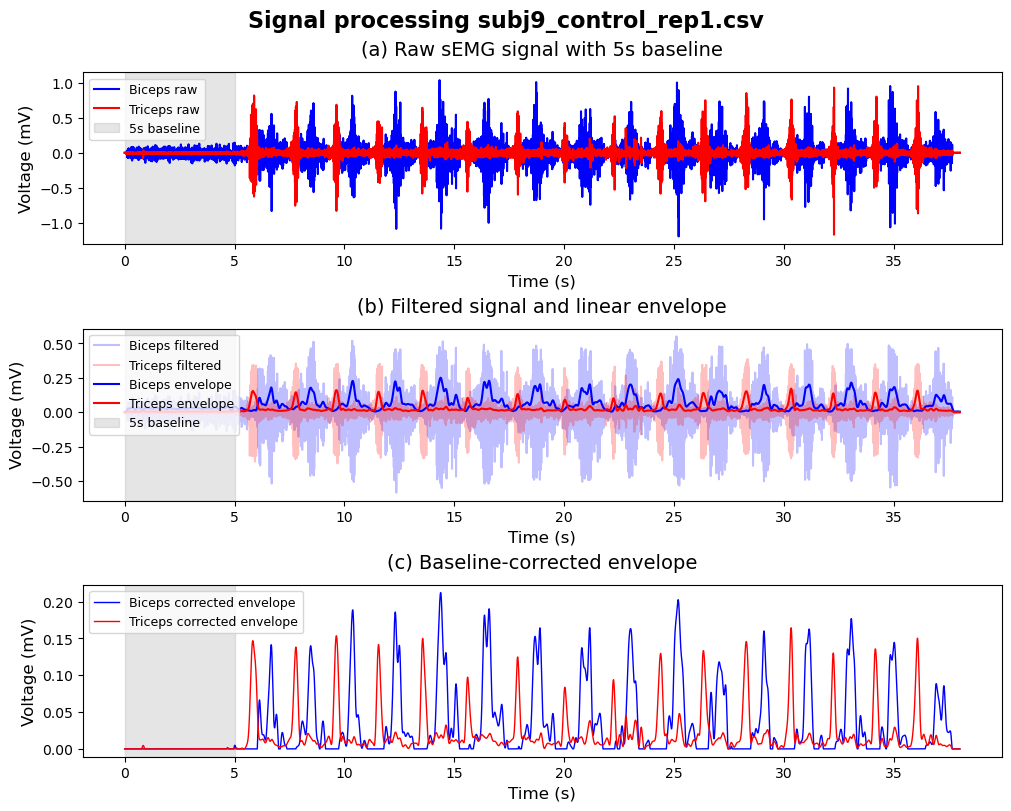

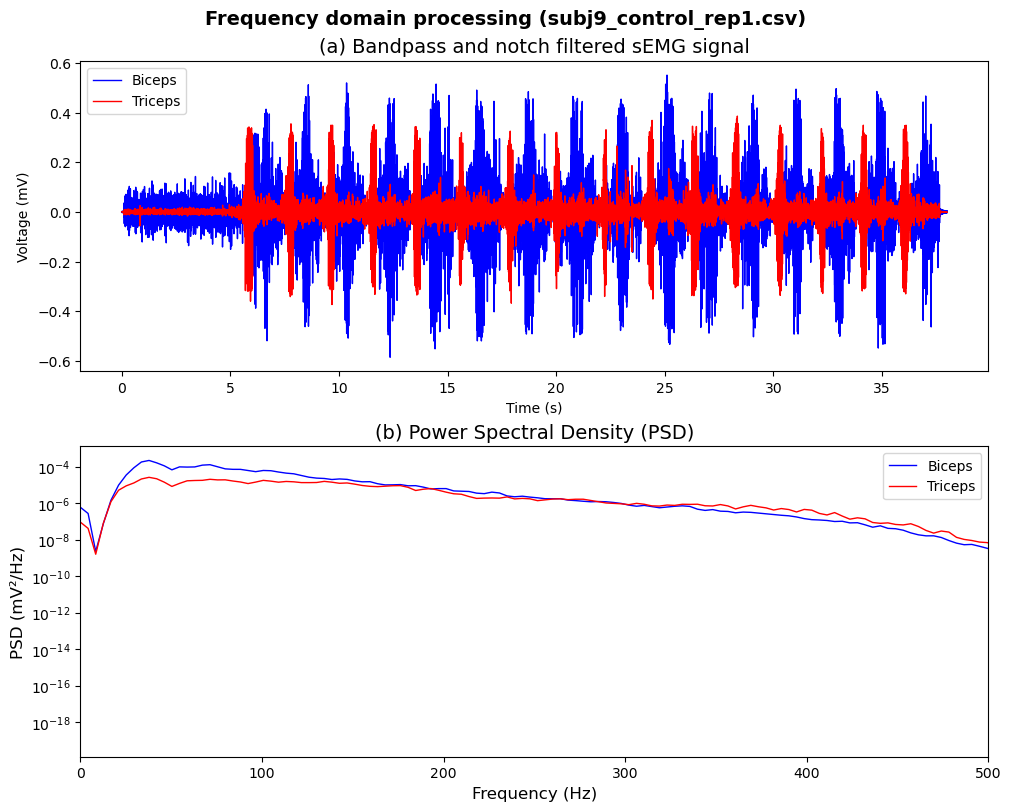

Signals synchronized


,patient,session,trial,file,biceps_rms,triceps_rms,biceps_rms_ratio,triceps_rms_ratio,coactivation_index,coactivation_index_ratio,biceps_mnf,triceps_mnf,biceps_mnf_ratio,triceps_mnf_ratio
0,subj1,control,1,subj1_control_rep1.csv,0.048332,0.012721,1.000000,1.000000,16.443274,1.000000,102.908529,75.805910,1.000000,1.000000
1,subj1,control,2,subj1_control_rep2.csv,0.041212,0.011810,0.852683,0.928323,19.197926,1.167525,102.806451,72.831020,0.999008,0.960756
2,subj1,control,3,subj1_control_rep3.csv,0.052060,0.009423,1.077141,0.740749,12.904798,0.784807,103.152540,86.177685,1.002371,1.136820
3,subj1,control,4,subj1_control_rep4.csv,0.052346,0.008039,1.083050,0.631932,15.660412,0.952390,104.136603,77.506085,1.011934,1.022428
4,subj1,fmv,1,subj1_fmv_rep1.csv,0.040378,0.009871,1.000000,1.000000,28.086029,1.000000,107.011019,71.969513,1.000000,1.000000


In [44]:
path = r"C:/CSV TFG/"

#1. Load dataset
dataset =  load_dataset(path, 2148)
print(f"Participants: {len(dataset)}")

#2. Signal processing
dataset = process_dataset(dataset)
print("Filtering and processing completed")

#3. Visualization of signal processing and filtering
visualize_filtering_steps(dataset["subj9"]["control"][0])
visualize_frequency_processing(dataset["subj9"]["control"][0])

#4. Synchronization
dataset = synchronize_dataset(dataset)
print("Signals synchronized")

#5. Feature extraction
features_df = feature_extraction(dataset)
features_df.head()

In [41]:
#6. Statistical analysis

intra_table = lmm_intra_summary(features_df)
inter_table = lmm_inter_summary(features_df)


#RMS
rms_intra = intra_table[intra_table["Variable"].isin(["Biceps RMS ratio", "Triceps RMS ratio"])]
rms_inter = inter_table[inter_table["Variable"].isin(["Biceps RMS ratio", "Triceps RMS ratio"])]
display(rms_intra)
display(rms_inter)

#CI
ci_intra = intra_table[intra_table["Variable"] == "CI ratio"]
ci_inter = inter_table[inter_table["Variable"] == "CI ratio"]
display(ci_intra)
display(ci_inter)

#MNF
mnf_intra = intra_table[intra_table["Variable"].isin(["Biceps MNF ratio", "Triceps MNF ratio"])]
mnf_inter = inter_table[inter_table["Variable"].isin(["Biceps MNF ratio", "Triceps MNF ratio"])]
display(mnf_intra)
display(mnf_inter)

C:\Users\marta\Anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\marta\Anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\marta\Anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\marta\Anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\marta\Anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\marta\Anaconda3\Lib\site-pack

,Variable,Session,Pre,Post,Post10,Post20
0,Biceps RMS ratio,control,1.000 ± 0.000,"0.908 ± 0.487,p = 0.063","0.841 ± 0.300,p = 0.038","0.830 ± 0.414,p = 0.007"
1,Biceps RMS ratio,fmv,1.000 ± 0.000,"0.855 ± 0.341,p = 0.026","0.796 ± 0.419,p < 0.001","0.904 ± 0.367,p = 0.121"
2,Triceps RMS ratio,control,1.000 ± 0.000,"1.291 ± 0.725,p = 0.281","1.355 ± 0.760,p = 0.194","1.191 ± 0.631,p = 0.615"
3,Triceps RMS ratio,fmv,1.000 ± 0.000,"0.778 ± 0.293,p < 0.001","0.809 ± 0.355,p = 0.001","0.850 ± 0.446,p = 0.002"


,Variable,Timepoint,Control,FMV,FMV vs Control
0,Biceps RMS ratio,Post,0.908 ± 0.487,0.855 ± 0.341,p = 0.817
1,Biceps RMS ratio,Post10,0.841 ± 0.300,0.796 ± 0.419,p = 0.446
2,Biceps RMS ratio,Post20,0.830 ± 0.414,0.904 ± 0.367,p = 0.317
3,Triceps RMS ratio,Post,1.291 ± 0.725,0.778 ± 0.293,p < 0.001
4,Triceps RMS ratio,Post10,1.355 ± 0.760,0.809 ± 0.355,p = 0.008
5,Triceps RMS ratio,Post20,1.191 ± 0.631,0.850 ± 0.446,p = 0.039


,Variable,Session,Pre,Post,Post10,Post20
4,CI ratio,control,1.000 ± 0.000,"1.426 ± 0.913,p = 0.423","1.055 ± 0.522,p = 0.762","1.214 ± 0.682,p = 0.503"
5,CI ratio,fmv,1.000 ± 0.000,"1.208 ± 0.809,p = 0.750","1.221 ± 0.817,p = 0.776","1.350 ± 1.071,p = 0.379"


,Variable,Timepoint,Control,FMV,FMV vs Control
6,CI ratio,Post,1.426 ± 0.913,1.208 ± 0.809,p = 0.151
7,CI ratio,Post10,1.055 ± 0.522,1.221 ± 0.817,p = 0.865
8,CI ratio,Post20,1.214 ± 0.682,1.350 ± 1.071,p = 0.290


,Variable,Session,Pre,Post,Post10,Post20
6,Biceps MNF ratio,control,1.000 ± 0.000,"1.058 ± 0.188,p = 0.097","1.066 ± 0.183,p = 0.049","1.098 ± 0.194,p = 0.002"
7,Biceps MNF ratio,fmv,1.000 ± 0.000,"1.031 ± 0.103,p = 0.095","1.027 ± 0.049,p = 0.099","1.034 ± 0.040,p = 0.037"
8,Triceps MNF ratio,control,1.000 ± 0.000,"1.009 ± 0.097,p = 0.865","1.032 ± 0.128,p = 0.360","1.015 ± 0.138,p = 0.829"
9,Triceps MNF ratio,fmv,1.000 ± 0.000,"0.994 ± 0.243,p = 0.437","0.994 ± 0.245,p = 0.438","0.968 ± 0.223,p = 0.154"


,Variable,Timepoint,Control,FMV,FMV vs Control
9,Biceps MNF ratio,Post,1.058 ± 0.188,1.031 ± 0.103,p = 0.594
10,Biceps MNF ratio,Post10,1.066 ± 0.183,1.027 ± 0.049,p = 0.374
11,Biceps MNF ratio,Post20,1.098 ± 0.194,1.034 ± 0.040,p = 0.116
12,Triceps MNF ratio,Post,1.009 ± 0.097,0.994 ± 0.243,p = 0.542
13,Triceps MNF ratio,Post10,1.032 ± 0.128,0.994 ± 0.245,p = 0.369
14,Triceps MNF ratio,Post20,1.015 ± 0.138,0.968 ± 0.223,p = 0.315


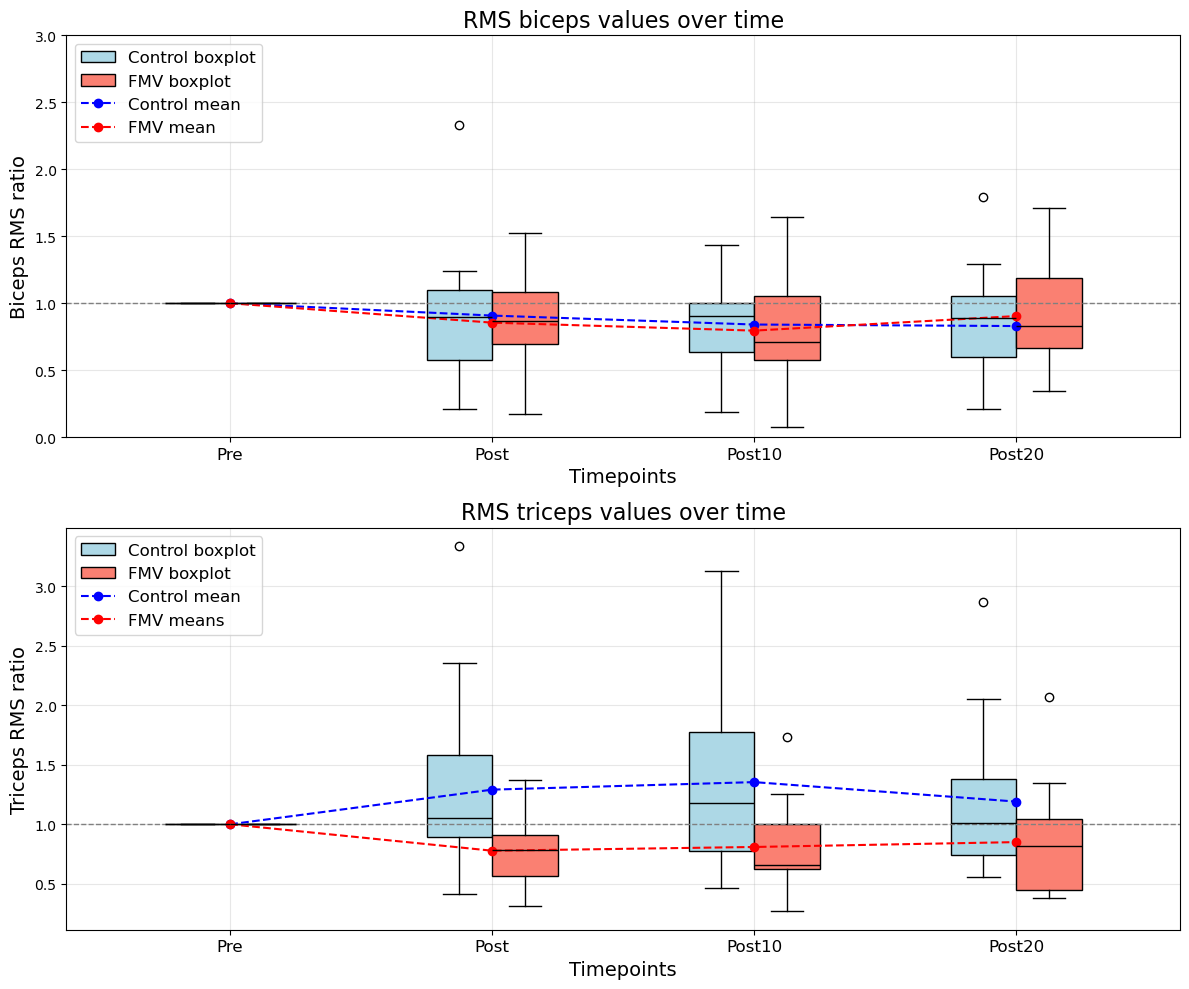

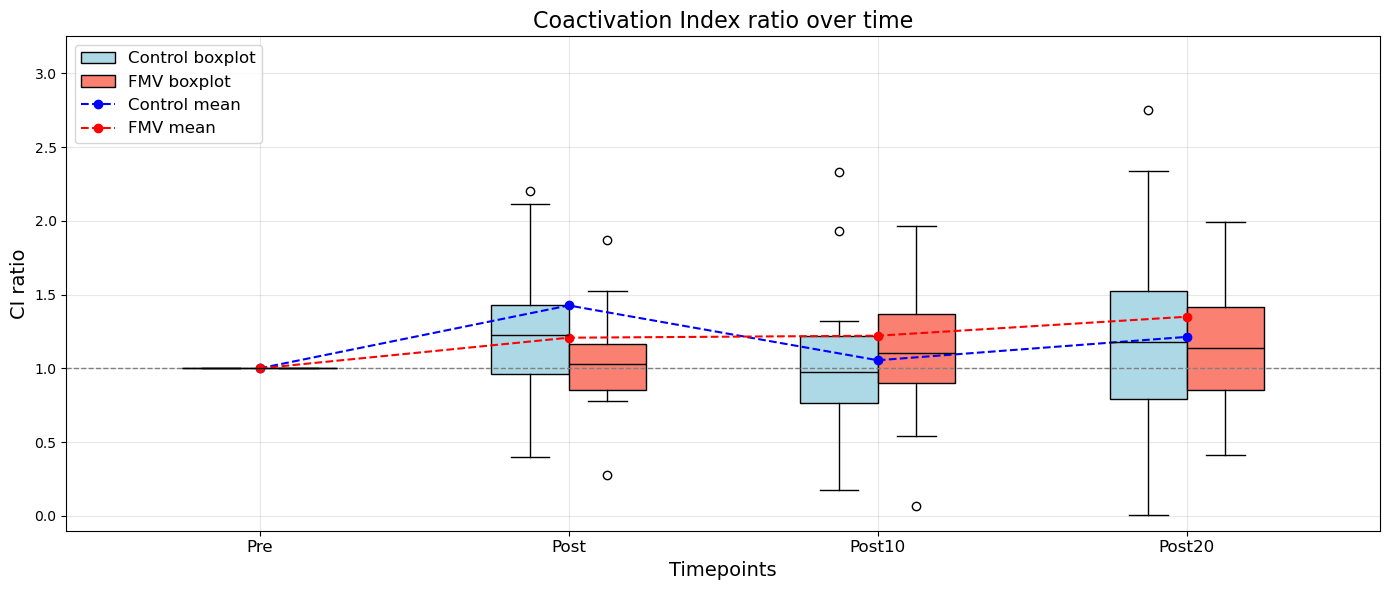

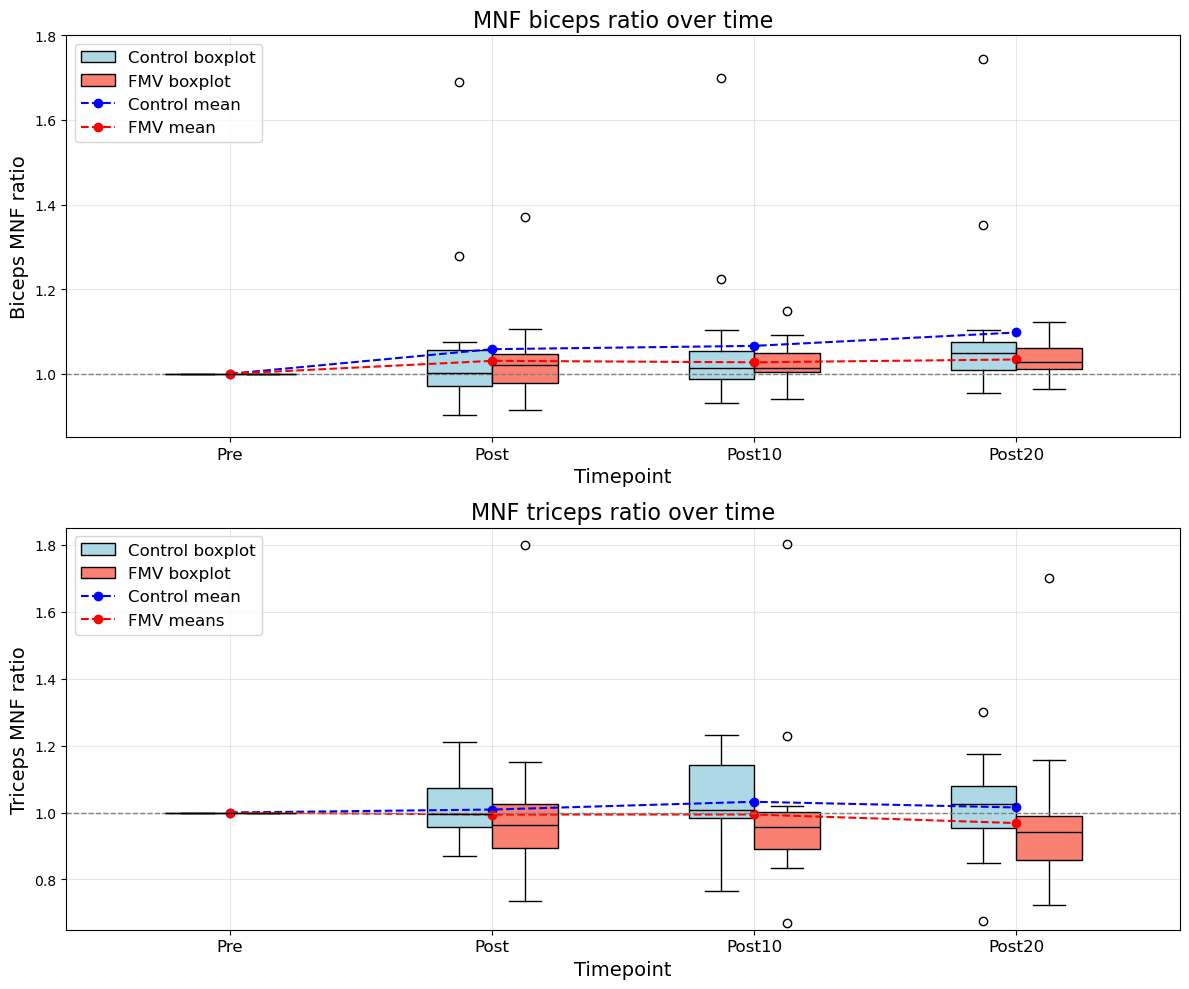

In [42]:
#7. Boxplots
plot_rms_boxplots(features_df)
plot_ci_boxplot(features_df)
plot_mnf_boxplots(features_df)